# FB Prophet Demonstration

As an example, let’s look at a time series of the log daily page views for the Wikipedia page for Peyton Manning. We scraped this data using the Wikipediatrend package in R. Peyton Manning provides a nice example because it illustrates some of Prophet’s features, like multiple seasonality, changing growth rates, and the ability to model special days (such as Manning’s playoff and superbowl appearances).

In [8]:
# Python

import pandas as pd
from prophet import Prophet

In [9]:
url = 'https://raw.githubusercontent.com/facebook/prophet/master/examples/example_wp_log_peyton_manning.csv'
df = pd.read_csv(url)
df.head()

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


In [10]:
# Python
m = Prophet()
m.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_5l06ezu/zozrsies.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_5l06ezu/bd388ib5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11995', 'data', 'file=/tmp/tmp_5l06ezu/zozrsies.json', 'init=/tmp/tmp_5l06ezu/bd388ib5.json', 'output', 'file=/tmp/tmp_5l06ezu/prophet_model26tqsgdn/prophet_model-20250429023936.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:39:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:39:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [11]:
# Python
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [12]:
# Python
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.210097,7.470147,8.940878
3266,2017-01-16,8.535122,7.769118,9.247219
3267,2017-01-17,8.322549,7.500310,9.052705
3268,2017-01-18,8.155179,7.397573,8.903743
3269,2017-01-19,8.167136,7.472258,8.919477


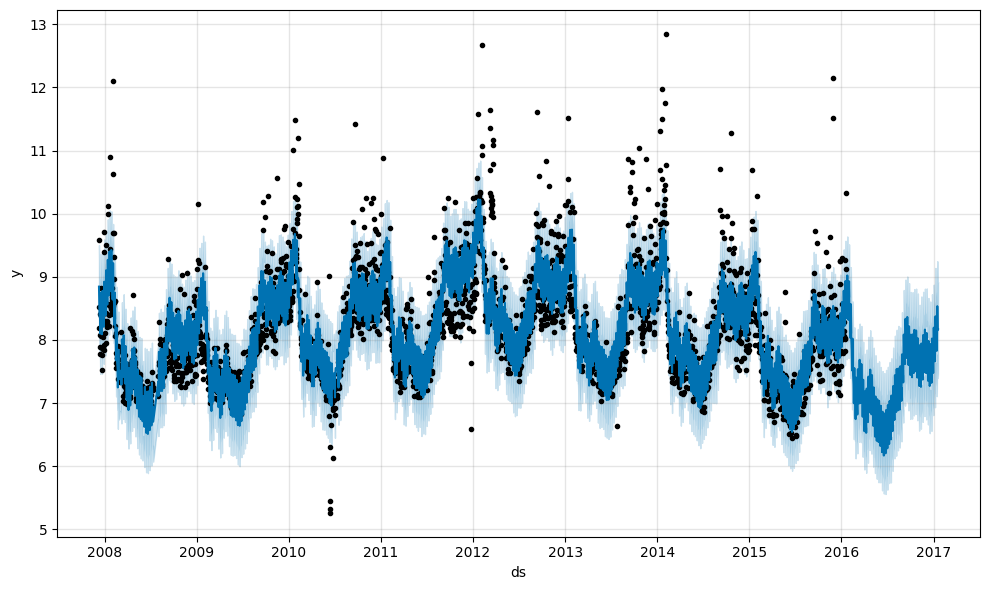

In [13]:
# Python
fig1 = m.plot(forecast)